In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns

In [50]:
wti = pd.read_csv("wti_prices.csv", parse_dates=['Date'])
wti = wti.sort_values('Date')

wti_price_col = 'WTI_price' 
wti['log_return'] = np.log(wti[wti_price_col]).diff()
wti_returns = wti['log_return'].dropna()

wti.head()

,Date,WTI_price,log_return
0,1986-01-01,22.93,NaN
1,1986-02-01,15.46,-0.394190
2,1986-03-01,12.61,-0.203766
3,1986-04-01,12.84,0.018075
4,1986-05-01,15.38,0.180503


In [ ]:
# predictors = pd.read_csv("predictor_data.csv", parse_dates=['Date'])
# predictors = predictors.sort_values('Date')
# predictors.head()

,Date,CPI,TB3MS,M1,M2,AUD_USD,CAD_USD,NZD_USD,ZAR_USD
0,1986-01-01,109.9,7.07,621.4,2502.1,0.700005,1.406981,0.516571,2.362762
1,1986-02-01,109.7,7.06,625.2,2512.9,0.699284,1.404284,0.531774,2.089716
2,1986-03-01,109.1,6.56,633.5,2533.1,0.707938,1.400910,0.528200,2.040943
3,1986-04-01,108.7,6.06,641.0,2557.8,0.722841,1.387868,0.561268,2.051609
4,1986-05-01,109.0,6.15,652.0,2584.8,0.727195,1.375719,0.566657,2.194029


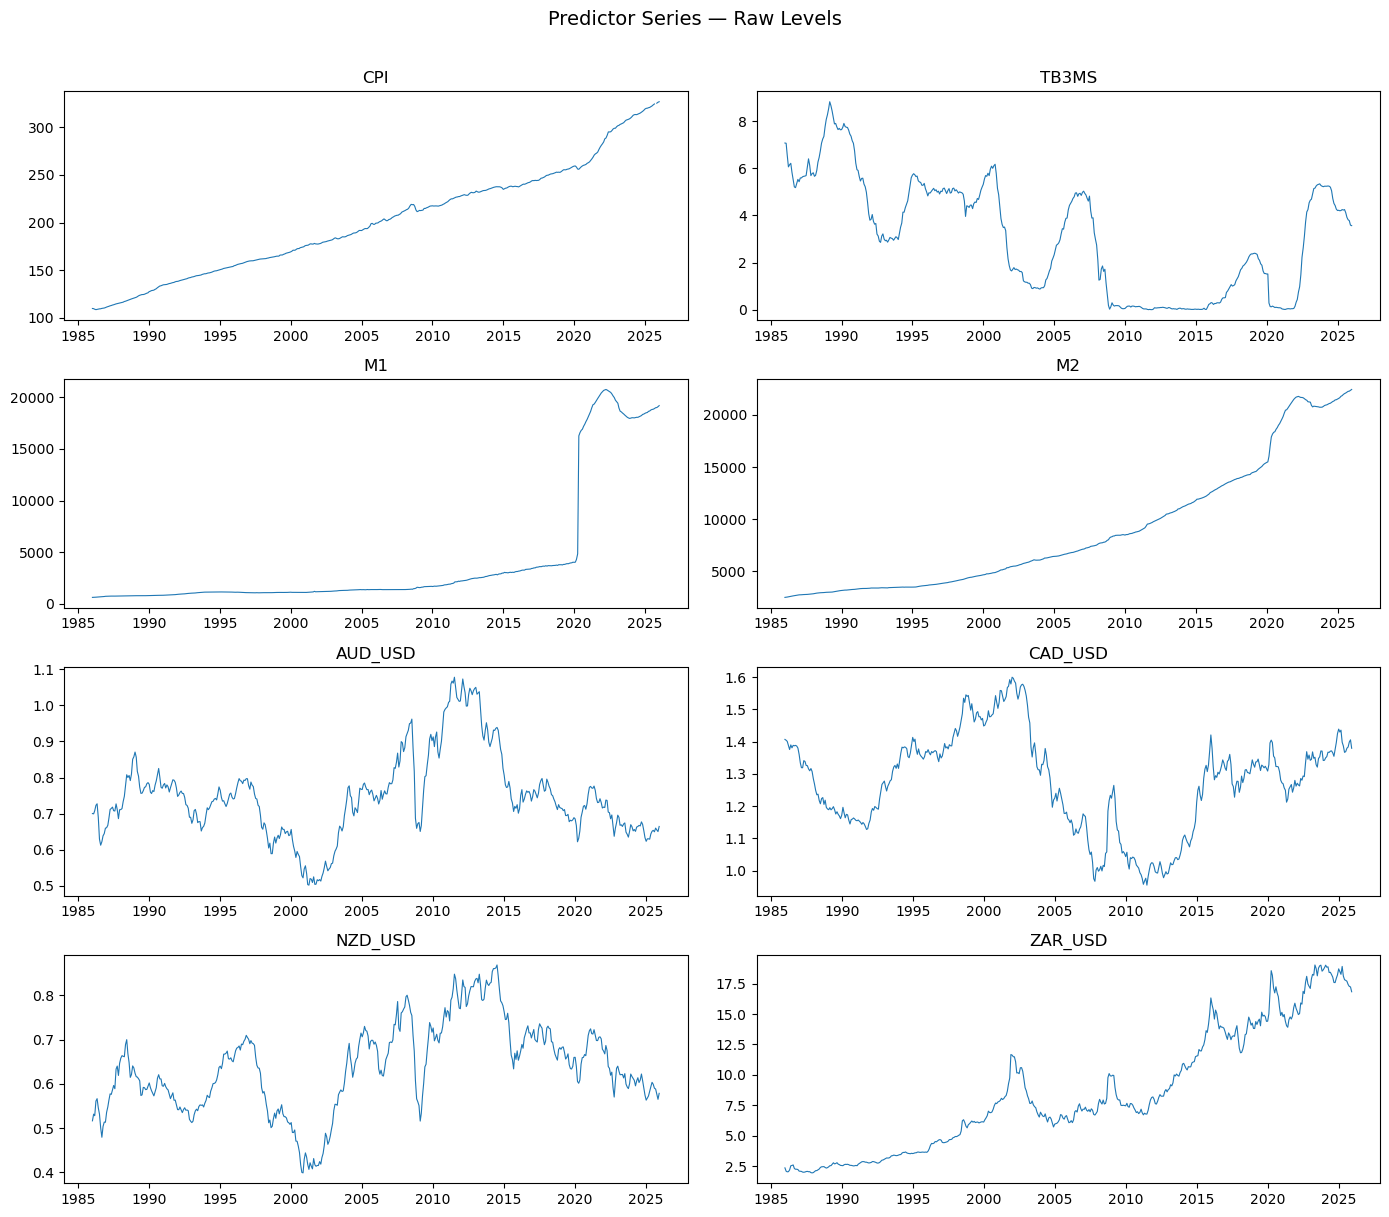

In [ ]:
# cols = ['CPI', 'TB3MS', 'M1', 'M2', 'AUD_USD', 'CAD_USD', 'NZD_USD', 'ZAR_USD']

# # --- Plot ---
# fig, axes = plt.subplots(4, 2, figsize=(14, 12))
# for ax, col in zip(axes.flatten(), cols):
#     ax.plot(predictors['Date'], predictors[col], linewidth=0.8)
#     ax.set_title(col)
#     ax.set_xlabel('')
# plt.suptitle('Predictor Series — Raw Levels', fontsize=14, y=1.01)
# plt.tight_layout()
# plt.show()

In [ ]:
# # --- ADF Tests ---
# print(f"{'Series':<12} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
# print("-" * 48)
# for col in cols:
#     result = adfuller(predictors[col].dropna(), autolag='AIC')
#     adf_stat, p_val = result[0], result[1]
#     stationary = 'Yes' if p_val < 0.05 else 'No'
#     print(f"{col:<12} {adf_stat:>10.3f} {p_val:>10.4f} {stationary:>12}")

Series         ADF Stat    p-value  Stationary?
------------------------------------------------
CPI               1.375     0.9970           No
TB3MS            -2.601     0.0928           No
M1                0.397     0.9814           No
M2                1.671     0.9981           No
AUD_USD          -2.224     0.1975           No
CAD_USD          -1.926     0.3197           No
NZD_USD          -2.475     0.1217           No
ZAR_USD          -0.591     0.8729           No


In [ ]:
# to_diff = cols # all nonstationary

# predictors_transformed = predictors.copy()

# for col in to_diff:
#     predictors_transformed[col] = predictors_transformed[col].diff()

# # Drop the NaN row introduced by differencing
# predictors_transformed = predictors_transformed.dropna().reset_index(drop=True)

# # --- Confirm stationarity post-differencing ---
# print(f"{'Series':<12} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
# print("-" * 48)
# for col in to_diff:
#     result = adfuller(predictors_transformed[col].dropna(), autolag='AIC')
#     adf_stat, p_val = result[0], result[1]
#     stationary = 'Yes' if p_val < 0.05 else 'No'
#     print(f"{col:<12} {adf_stat:>10.3f} {p_val:>10.4f} {stationary:>12}")

# predictors_transformed.head()

Series         ADF Stat    p-value  Stationary?
------------------------------------------------
CPI              -3.381     0.0116          Yes
TB3MS            -4.720     0.0001          Yes
M1              -20.067     0.0000          Yes
M2               -3.959     0.0016          Yes
AUD_USD         -14.143     0.0000          Yes
CAD_USD         -16.492     0.0000          Yes
NZD_USD         -16.308     0.0000          Yes
ZAR_USD         -14.409     0.0000          Yes


,Date,CPI,TB3MS,M1,M2,AUD_USD,CAD_USD,NZD_USD,ZAR_USD
0,1986-02-01,-0.2,-0.01,3.8,10.8,-0.000721,-0.002697,0.015202,-0.273046
1,1986-03-01,-0.6,-0.50,8.3,20.2,0.008654,-0.003375,-0.003574,-0.048773
2,1986-04-01,-0.4,-0.50,7.5,24.7,0.014903,-0.013041,0.033068,0.010666
3,1986-05-01,0.3,0.09,11.0,27.0,0.004354,-0.012149,0.005389,0.142419
4,1986-06-01,0.4,0.06,8.6,20.2,-0.038329,0.014195,-0.020805,0.342181


In [ ]:
# # append wti to selected predictors (treasury rate)
# df_raw = wti[['Date', 'log_return']].merge(predictors_transformed[['Date', 'TB3MS']], on='Date', how='inner')
# df_raw.dropna(inplace=True)
# df_raw.head()

,Date,log_return,TB3MS
0,1986-02-01,-0.394190,-0.01
1,1986-03-01,-0.203766,-0.50
2,1986-04-01,0.018075,-0.50
3,1986-05-01,0.180503,0.09
4,1986-06-01,-0.135577,0.06


In [ ]:
predictors = pd.read_csv("tb3ms.csv", parse_dates=['date'])
predictors = predictors.rename(columns={'date': 'Date', 'TB3MS': 'TB3MS'})
predictors = predictors.sort_values('Date')
df_raw = wti[['Date', 'log_return']].merge(predictors[['Date', 'TB3MS']], on='Date', how='inner')
df_raw.dropna(inplace=True)
df_raw.head()

# Gaussian Noise Injection
- adding noise to training data

$$
\epsilon_t \sim \mathcal{N}(0, \alpha^2 \sigma_Y^2)
$$

-  $\alpha=0.03$ from literature -> take 3% of signal's standard deviation
- jittering data prep:
    - add lagged target to pred data
    - split train/val/test
    - add noise $\epsilon \sim \mathscr{N}(0,\alpha^2) $

In [56]:
n = len(df_raw)
train_end = int(n * 0.70) # 70/15/15 split
val_end   = int(n * 0.85)

train_df = df_raw.iloc[:train_end].copy()
val_df   = df_raw.iloc[train_end:val_end].copy()
test_df  = df_raw.iloc[val_end:].copy()

print(f"Train: {len(train_df)} rows ({train_df['Date'].iloc[0].date()} to {train_df['Date'].iloc[-1].date()})")
print(f"Val:   {len(val_df)} rows ({val_df['Date'].iloc[0].date()} to {val_df['Date'].iloc[-1].date()})")
print(f"Test:  {len(test_df)} rows ({test_df['Date'].iloc[0].date()} to {test_df['Date'].iloc[-1].date()})")

Train: 333 rows (1986-02-01 to 2013-10-01)
Val:   72 rows (2013-11-01 to 2019-10-01)
Test:  72 rows (2019-11-01 to 2025-12-01)


In [57]:
# add lag Y to covariates (for jittering lagged Y while keeping target col clean)
def add_lag(df):
    df = df.copy()
    df['Y_lag1'] = df['log_return'].shift(1)
    df = df.dropna().reset_index(drop=True)  # drops first row where lag is NaN
    return df

train_wlags = add_lag(train_df)
val_wlags   = add_lag(val_df)
test_wlags  = add_lag(test_df)

print("Columns:", train_wlags.columns.tolist())
print("Train shape:", train_wlags.shape)

Columns: ['Date', 'log_return', 'TB3MS', 'Y_lag1']
Train shape: (332, 4)


In [58]:
train_wlags.head()

,Date,log_return,TB3MS,Y_lag1
0,1986-03-01,-0.203766,-0.50,-0.394190
1,1986-04-01,0.018075,-0.50,-0.203766
2,1986-05-01,0.180503,0.09,0.018075
3,1986-06-01,-0.135577,0.06,0.180503
4,1986-07-01,-0.147348,-0.38,-0.135577


In [59]:
# --- jittering function
def jitter_df(
    train_data: pd.DataFrame,
    exclude_cols: list = ['log_return', 'Date'],
    alpha: float = 0.03,
    num_copies: int = 1,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Jitter training data by adding Gaussian noise scaled to each column's own std.
    Noise for column c: ε ~ N(0, (alpha * std(c))²)
    Original data is always included as sample_id = 0.

    Params:
        train_data   : original training DataFrame in original levels
        exclude_cols : columns to exclude from jittering (target, date, etc.)
        alpha        : noise as fraction of each series' own std
        num_copies   : number of jittered copies to generate
        random_state : reproducibility seed

    Returns:
        DataFrame with all original + jittered copies and a 'sample_id' column.
        sample_id = 0 is the original, sample_id = 1..num_copies are jittered.
    """
    jitter_cols = [c for c in train_data.columns if c not in exclude_cols]
    noise_scales = alpha * train_data[jitter_cols].std()
    rng = np.random.default_rng(random_state)

    original = train_data.copy()
    original['sample_id'] = 0
    copies = [original]

    for i in range(1, num_copies + 1):
        copy = train_data.copy()
        for col in jitter_cols:
            noise = rng.normal(loc=0, scale=noise_scales[col], size=len(copy))
            copy[col] = copy[col] + noise
        copy['sample_id'] = i
        copies.append(copy)

    return pd.concat(copies, ignore_index=True)

In [60]:
# --- apply jittering
ALPHA = 0.03 
K_COPIES  = 10     # number of augmented copies
SEED      = 4101

train_augmented = jitter_df(train_wlags, 
                            exclude_cols=['log_return', 'Date'],
                            alpha=ALPHA, num_copies=K_COPIES, random_state=SEED)

print(f"Original train size:  {len(train_wlags)}")
print(f"Augmented train size: {len(train_augmented)}  ({K_COPIES+1}xoriginal)")

Original train size:  332
Augmented train size: 3652  (11xoriginal)


In [65]:
# --- save augmented data
train_augmented.to_csv("train_augmented.csv", index=False)

### Plotting one sample

In [66]:
# inspect jittered data
full_augmented = pd.read_csv("train_augmented.csv", parse_dates=['Date'])
plot_augmented = train_augmented[train_augmented['sample_id']==1].copy() # inspect first jittered sample
plot_augmented = plot_augmented.drop(columns=['sample_id'])

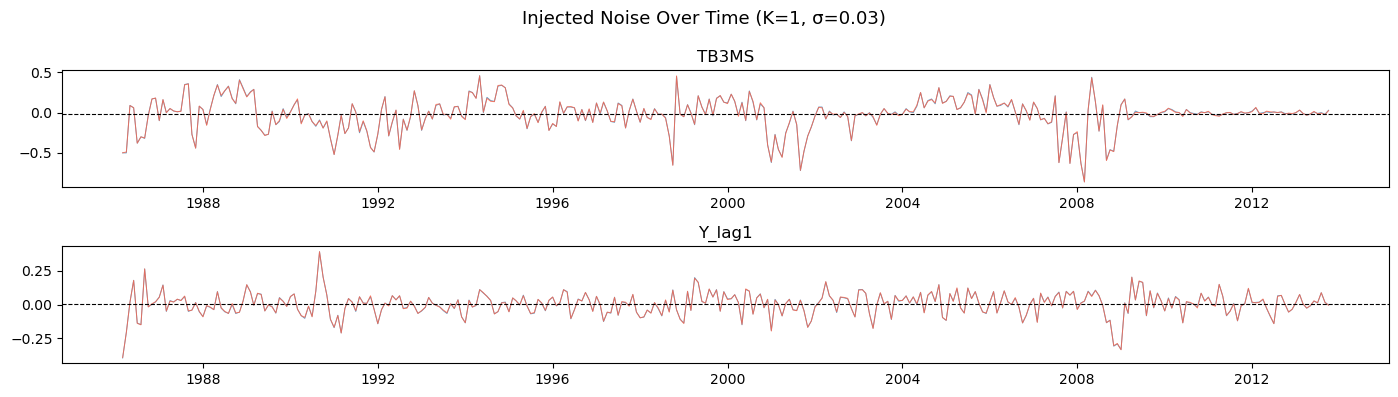

In [63]:
# plot jittered data
plot_cols = train_wlags.columns.difference(['Date', 'log_return']).tolist() # only covariates
num_plots = len(plot_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 2*num_plots), sharex=False)

for ax, col in zip(axes, plot_cols):
    orig     = train_wlags[col].values
    jittered = plot_augmented.iloc[:len(train_wlags)][col].values
    # noise    = jittered - orig

    # ax.plot(train_wlags['Date'], noise,
    #         color='tomato', linewidth=0.7, alpha=0.8)
    ax.plot(train_wlags['Date'], orig,
        color='steelblue', linewidth=0.7, alpha=0.8)
    ax.plot(train_wlags['Date'], jittered,
        color='tomato', linewidth=0.7, alpha=0.8)
    ax.axhline(np.mean(orig), color='black', linewidth=0.8, linestyle='--')
    ax.set_title(col)
    # ax.set_ylim(-0.15, 0.15)  # compress y axis to noise range

plt.suptitle('Injected Noise Over Time (K=1, σ=0.03)', fontsize=13)
plt.tight_layout()
plt.show()

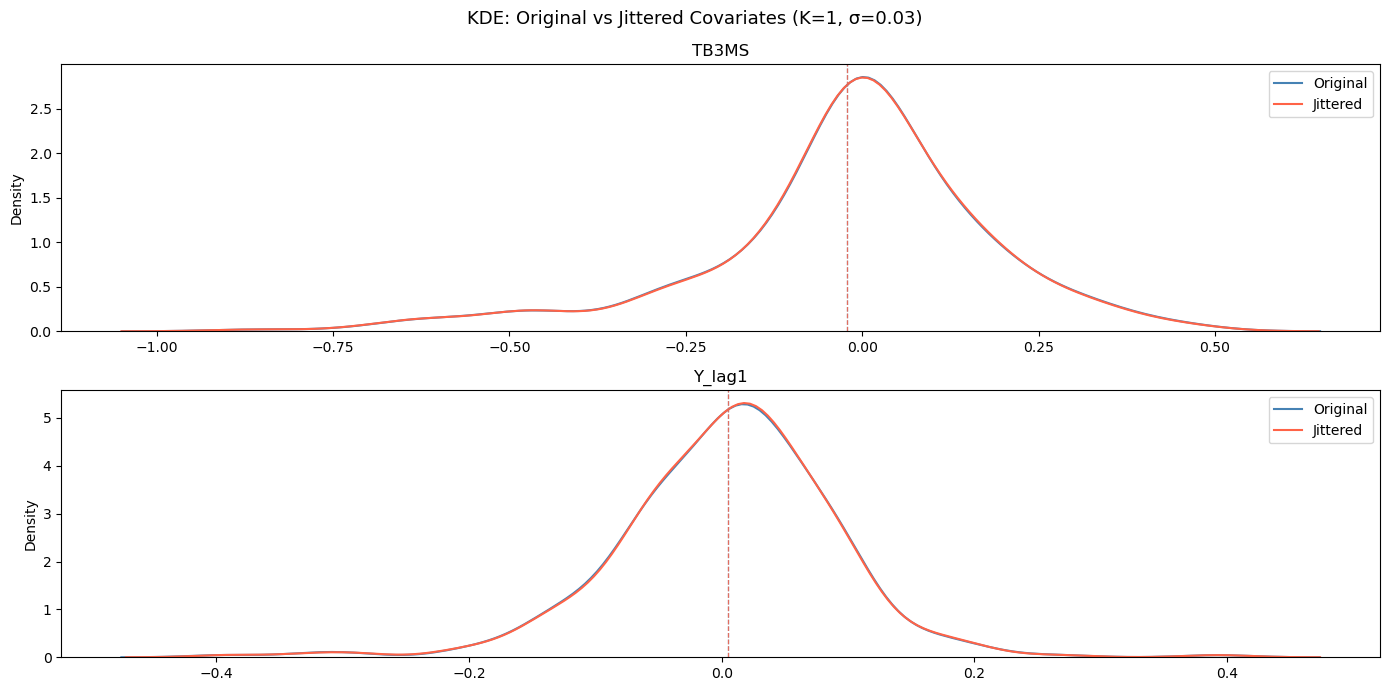

In [64]:
plot_cols = train_wlags.columns.difference(['Date', 'log_return']).tolist()

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 3.5 * len(plot_cols)), sharex=False)

if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    orig = train_wlags[col].dropna().values
    jittered = plot_augmented.iloc[:len(train_wlags)][col].dropna().values

    sns.kdeplot(orig, ax=ax, label='Original', color='steelblue', linewidth=1.5)
    sns.kdeplot(jittered, ax=ax, label='Jittered', color='tomato', linewidth=1.5)

    ax.axvline(np.mean(orig), color='steelblue', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.axvline(np.mean(jittered), color='tomato', linestyle='--', linewidth=0.9, alpha=0.8)

    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('KDE: Original vs Jittered Covariates (K=1, σ=0.03)', fontsize=13)
plt.tight_layout()
plt.show()